# Wide World Importers - Sales Analysis

## Exploratory Data Analysis (EDA)

This notebook contains the initial exploratory analysis of the WWI sales dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Verificar el limitador
with open("../data/ventas_wwi.csv", "r") as file:
    for i in range(5):
        print(file.readline())


﻿2013-01-01;48;Sara Huiting;905;7;Bock;"""The Gu"" red shirt XML tag t-shirt (Black) 6XL";100;NULL;Fabrikam, Inc.;4;4;Hudson Onslow;3;72;72;18.00;15.000;1296.00

2013-01-01;48;Sara Huiting;905;7;Bock;Pack of 12 action figures (male);151;NULL;Contoso, Ltd.;2;2;Hudson Onslow;3;8;8;16.00;15.000;128.00

2013-01-01;11;Wingtip Toys (Lynne, FL);586;7;Lynne;Developer joke mug - there are 10 types of people in the world (Black);45;NULL;Graphic Design Institute;5;2;Hudson Onslow;3;1;1;13.00;15.000;13.00

2013-01-01;70;Tailspin Toys (Sans Souci, SC);92;7;Sans Souci;Black and orange fragile despatch tape 48mmx75m;191;NULL;Litware, Inc.;7;5;Sophia Hinton;6;144;144;3.70;15.000;532.80

2013-01-01;70;Tailspin Toys (Sans Souci, SC);92;7;Sans Souci;IT joke mug - that behavior is by design (Black);55;NULL;Graphic Design Institute;5;2;Sophia Hinton;6;3;3;13.00;15.000;39.00



In [3]:
# cargar archivo
ruta = "../data/ventas_wwi2.csv"
df = pd.read_csv(ruta, sep=";")
df.head()

,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,Halloween zombie mask (Light Brown) M,143,NULL,"Fabrikam, Inc.",...,4.1,Anthony Grosse,8,24,24.1,18.00,15.000,378187,19.00,432.00
0,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,"""The Gu"" red shirt XML tag t-shirt (Black) 5XL",99,NaN,"Fabrikam, Inc.",...,4,Anthony Grosse,8,120,120,18.0,15.0,282132,8.0,2160.0
1,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,Developer joke mug - that's a hardware problem...,33,NaN,Graphic Design Institute,...,2,Anthony Grosse,8,10,10,13.0,15.0,60005,4.5,130.0
2,2014-07-25,31549,Shantanu Huq,930,7,Cramerton,DBA joke mug - I will get you in order (White),24,NaN,Graphic Design Institute,...,2,Archer Lamble,16,8,8,13.0,15.0,57083,4.5,104.0
3,2014-07-25,31549,Shantanu Huq,930,7,Cramerton,Halloween skull mask (Gray) M,147,NaN,"Fabrikam, Inc.",...,4,Archer Lamble,16,12,12,18.0,15.0,354456,15.0,216.0
4,2014-07-25,31549,Shantanu Huq,930,7,Cramerton,DBA joke mug - mind if I join you? (White),16,NaN,Graphic Design Institute,...,2,Archer Lamble,16,8,8,13.0,15.0,51836,4.5,104.0


In [4]:
# Creamos los headers para agregar al data set guiados por el query usado para extraer los datos de la BD
columns = [
    "OrderDate",
    "OrderID",
    "CustomerName",
    "CustomerID",
    "PaymentDays",
    "CityName",
    "StockItemName",
    "StockItemID",
    "Brand",
    "SupplierName",
     "SupplierID",
    "SupplierCategoryID",
    "Vendor",
    "VendorID",
    "Quantity",
    "PickedQuantity",
    "SaleUnitPrice",
    "TaxRate",
    "QuantityOnHand",
    "LastCostPrice",
    "Revenue"
]

df = pd.read_csv(
    ruta,
    sep=";",
    header=None,
    names=columns
)
df.head()

,OrderDate,OrderID,CustomerName,CustomerID,PaymentDays,CityName,StockItemName,StockItemID,Brand,SupplierName,...,SupplierCategoryID,Vendor,VendorID,Quantity,PickedQuantity,SaleUnitPrice,TaxRate,QuantityOnHand,LastCostPrice,Revenue
0,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,Halloween zombie mask (Light Brown) M,143,NaN,"Fabrikam, Inc.",...,4,Anthony Grosse,8,24,24,18.0,15.0,378187,19.0,432.0
1,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,"""The Gu"" red shirt XML tag t-shirt (Black) 5XL",99,NaN,"Fabrikam, Inc.",...,4,Anthony Grosse,8,120,120,18.0,15.0,282132,8.0,2160.0
2,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,Developer joke mug - that's a hardware problem...,33,NaN,Graphic Design Institute,...,2,Anthony Grosse,8,10,10,13.0,15.0,60005,4.5,130.0
3,2014-07-25,31549,Shantanu Huq,930,7,Cramerton,DBA joke mug - I will get you in order (White),24,NaN,Graphic Design Institute,...,2,Archer Lamble,16,8,8,13.0,15.0,57083,4.5,104.0
4,2014-07-25,31549,Shantanu Huq,930,7,Cramerton,Halloween skull mask (Gray) M,147,NaN,"Fabrikam, Inc.",...,4,Archer Lamble,16,12,12,18.0,15.0,354456,15.0,216.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231412 entries, 0 to 231411
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   OrderDate           231412 non-null  object 
 1   OrderID             231412 non-null  int64  
 2   CustomerName        231412 non-null  object 
 3   CustomerID          231412 non-null  int64  
 4   PaymentDays         231412 non-null  int64  
 5   CityName            231412 non-null  object 
 6   StockItemName       231412 non-null  object 
 7   StockItemID         231412 non-null  int64  
 8   Brand               18937 non-null   object 
 9   SupplierName        231412 non-null  object 
 10  SupplierID          231412 non-null  int64  
 11  SupplierCategoryID  231412 non-null  int64  
 12  Vendor              231412 non-null  object 
 13  VendorID            231412 non-null  int64  
 14  Quantity            231412 non-null  int64  
 15  PickedQuantity      231412 non-nul

In [6]:
df.describe()

,OrderID,CustomerID,PaymentDays,StockItemID,SupplierID,SupplierCategoryID,VendorID,Quantity,PickedQuantity,SaleUnitPrice,TaxRate,QuantityOnHand,LastCostPrice,Revenue
count,231412.000000,231412.000000,231412.0,231412.000000,231412.000000,231412.000000,231412.000000,231412.000000,231412.000000,231412.000000,231412.000000,2.314120e+05,231412.000000,231412.000000
mean,36644.884729,528.758301,7.0,110.292111,6.102130,3.663483,10.416223,40.235182,38.678323,45.207066,14.977616,1.342764e+05,23.077639,767.610480
std,21241.362015,343.774928,0.0,63.580908,2.435513,1.178471,5.720650,55.138491,54.376563,138.949335,0.333798,1.466480e+05,82.610295,1446.640756
min,1.000000,1.000000,7.0,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000,0.660000,10.000000,3.000000e+00,0.360000,2.500000
25%,18248.000000,160.000000,7.0,55.000000,4.000000,2.000000,6.000000,5.000000,5.000000,13.000000,15.000000,4.751200e+04,4.500000,96.000000
50%,36595.500000,518.000000,7.0,110.000000,5.000000,4.000000,13.000000,10.000000,9.000000,18.000000,15.000000,7.637300e+04,8.000000,240.000000
75%,55021.000000,877.000000,7.0,165.000000,7.000000,5.000000,15.000000,60.000000,60.000000,32.000000,15.000000,1.923580e+05,15.000000,888.000000
max,73595.000000,1061.000000,7.0,227.000000,12.000000,5.000000,20.000000,360.000000,360.000000,1899.000000,15.000000,1.034169e+06,1140.000000,18990.000000


In [7]:
# Verificar tipos de datos
type(df["OrderDate"][0])

str

In [8]:
# Cambiar fechas de str a datetime
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
type(df["OrderDate"][0])

pandas._libs.tslibs.timestamps.Timestamp

In [9]:
# Buscando decimales innecesarios
df[df["Quantity"] % 1 != 0][["Quantity"]].head()

,Quantity


In [10]:
df[df["PickedQuantity"] % 1 != 0][["PickedQuantity"]].head()

,PickedQuantity


In [11]:
df[df["VendorID"] % 1 != 0][["VendorID"]].head()

,VendorID


In [12]:
df[df["StockItemID"] % 1 != 0][["StockItemID"]].head()

,StockItemID


In [13]:
df[df["LastCostPrice"] % 1 != 0][["LastCostPrice"]].head()

,LastCostPrice
2,4.5
3,4.5
5,4.5
6,7.5
7,88.5


In [14]:
# Como realmente no hay decimales innecesarios, convertimos a enteros
columnas_a_enteros = ["OrderID","CustomerID","PaymentDays","StockItemID","SupplierID","SupplierCategoryID","VendorID","Quantity","PickedQuantity","TaxRate","QuantityOnHand"]
df[columnas_a_enteros] = df[columnas_a_enteros].astype("int32")
df.head()

,OrderDate,OrderID,CustomerName,CustomerID,PaymentDays,CityName,StockItemName,StockItemID,Brand,SupplierName,...,SupplierCategoryID,Vendor,VendorID,Quantity,PickedQuantity,SaleUnitPrice,TaxRate,QuantityOnHand,LastCostPrice,Revenue
0,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,Halloween zombie mask (Light Brown) M,143,NaN,"Fabrikam, Inc.",...,4,Anthony Grosse,8,24,24,18.0,15,378187,19.0,432.0
1,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,"""The Gu"" red shirt XML tag t-shirt (Black) 5XL",99,NaN,"Fabrikam, Inc.",...,4,Anthony Grosse,8,120,120,18.0,15,282132,8.0,2160.0
2,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,Developer joke mug - that's a hardware problem...,33,NaN,Graphic Design Institute,...,2,Anthony Grosse,8,10,10,13.0,15,60005,4.5,130.0
3,2014-07-25,31549,Shantanu Huq,930,7,Cramerton,DBA joke mug - I will get you in order (White),24,NaN,Graphic Design Institute,...,2,Archer Lamble,16,8,8,13.0,15,57083,4.5,104.0
4,2014-07-25,31549,Shantanu Huq,930,7,Cramerton,Halloween skull mask (Gray) M,147,NaN,"Fabrikam, Inc.",...,4,Archer Lamble,16,12,12,18.0,15,354456,15.0,216.0


In [15]:
# Nulos 
df.isnull().sum()

OrderDate                  0
OrderID                    0
CustomerName               0
CustomerID                 0
PaymentDays                0
CityName                   0
StockItemName              0
StockItemID                0
Brand                 212475
SupplierName               0
SupplierID                 0
SupplierCategoryID         0
Vendor                     0
VendorID                   0
Quantity                   0
PickedQuantity             0
SaleUnitPrice              0
TaxRate                    0
QuantityOnHand             0
LastCostPrice              0
Revenue                    0
dtype: int64

In [16]:
# Reemplazamos los null por unbranded en las categorias
df["Brand"] = df["Brand"].fillna("Unbranded")
df["Brand"].isnull().sum()

0

In [17]:
# Verificar duplicados
df.duplicated().sum()
#No hay duplicados, si los hubiera los verificariamos con: df[df.duplicated()] o con df[df.duplicated()].head()

0

### cardinalidad vs frecuencia de categorías

Cardinalidad
cuántos valores únicos tiene una columna

| Dimensión     | Qué vemos            |
| ------------- | ------------------------- |
| CustomerName  | cantidad de clientes      |
| CityName      | cobertura geográfica      |
| StockItemName | variedad de catálogo      |
| SupplierName  | diversidad de proveedores |
| Vendor        | cantidad de vendedores    |

Frecuencia de categorías
Cuantas veces aparece en el dataset

| Resultado               | Posible significado    |
| ----------------------- | ---------------------- |
| cliente aparece mucho   | alta recurrencia       |
| producto aparece mucho  | alta rotación          |
| ciudad aparece mucho    | mercado fuerte         |
| proveedor aparece mucho | dependencia comercial  |
| vendedor aparece mucho  | alto volumen operativo |


In [18]:
df["CustomerName"].nunique()

663

In [19]:
df["CustomerName"].value_counts().head(10)

CustomerName
Tailspin Toys (Vidrine, LA)             461
Bhaavan Rai                             460
Aleksandrs Riekstins                    457
Tailspin Toys (Tolna, ND)               454
Om Yadav                                450
Wingtip Toys (Key Biscayne, FL)         449
Tailspin Toys (North Crows Nest, IN)    448
Bishwa Chatterjee                       446
Wingtip Toys (West Frostproof, FL)      444
Tailspin Toys (Peeples Valley, AZ)      443
Name: count, dtype: int64

In [20]:
df["CityName"].nunique()

655

In [21]:
df["CityName"].value_counts().head(10)

CityName
Sinclair              751
East Fultonham        749
Akhiok                743
Teutopolis            731
Rockwall              685
Cherry Grove Beach    684
Vidrine               461
Chalco                460
La Bolt               457
Tolna                 454
Name: count, dtype: int64

In [22]:
df["StockItemName"].nunique()

227

In [23]:
df["StockItemName"].value_counts().head(10)

StockItemName
Alien officer hoodie (Black) 3XL                         1123
Dinosaur battery-powered slippers (Green) L              1123
10 mm Anti static bubble wrap (Blue) 50m                 1119
USB food flash drive - shrimp cocktail                   1117
20 mm Double sided bubble wrap 20m                       1110
"The Gu" red shirt XML tag t-shirt (White) 7XL           1110
Animal with big feet slippers (Brown) XL                 1108
10 mm Anti static bubble wrap (Blue) 10m                 1104
Ride on vintage American toy coupe (Black) 1/12 scale    1103
DBA joke mug - two types of DBAs (White)                 1102
Name: count, dtype: int64

In [24]:
df["SupplierName"].nunique()

7

In [25]:
df["SupplierName"].value_counts().head(3)

SupplierName
Fabrikam, Inc.              77618
Litware, Inc.               70259
Graphic Design Institute    44577
Name: count, dtype: int64

In [26]:
df["Vendor"].nunique()

10

In [27]:
df["Vendor"].value_counts().head(3)

Vendor
Archer Lamble     23684
Kayla Woodcock    23401
Taj Shand         23279
Name: count, dtype: int64

### Revenue por clientes, vendedor, ciudad, proveedor
concentración de ingresos
clientes más valiosos
desempeño comercial
mercados fuertes
qué proveedores están detrás de los productos más rentables

In [28]:
df.groupby("CustomerName")["Revenue"].sum().head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x","."))


CustomerName
Aakriti Byrraju        304.633,40
Abel Spirlea           262.720,20
Abel Tatarescu         155.660,05
Abhra Ganguly           59.971,35
Adrian Andreasson      272.513,95
Adriana Pena            63.375,45
Agrita Abele            22.829,65
Agrita Kanepa          279.339,15
Aishwarya Dantuluri    170.806,10
Aive Petrov            263.245,30
Name: Revenue, dtype: object

In [29]:
df.groupby("Vendor")["Revenue"].sum().head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x","."))

Vendor
Amy Trefl             17.329.344,05
Anthony Grosse        17.300.382,20
Archer Lamble         18.551.146,95
Hudson Hollinworth    17.716.354,25
Hudson Onslow         17.815.605,10
Jack Potter           17.621.145,20
Kayla Woodcock        18.107.095,00
Lily Code             17.612.639,80
Sophia Hinton         17.768.199,25
Taj Shand             17.812.364,60
Name: Revenue, dtype: object

In [30]:
df.groupby("CityName")["Revenue"].sum().head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x","."))

CityName
Abbottsburg      358.675,15
Absecon          270.119,45
Accomac          310.131,40
Aceitunas        246.351,40
Airport Drive    336.123,15
Akhiok           562.585,20
Alcester         263.725,40
Alden Bridge     323.447,05
Alstead          211.215,60
Amado            290.448,25
Name: Revenue, dtype: object

In [31]:
df.groupby("SupplierName")["Revenue"].sum().head(5).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x","."))

SupplierName
A Datum Corporation           1.142.515,20
Contoso, Ltd.                   275.120,00
Fabrikam, Inc.               50.375.684,00
Graphic Design Institute      3.172.130,00
Litware, Inc.               102.102.666,75
Name: Revenue, dtype: object

### Análisis de Distribuciones y Detección de Outliers

Con el objetivo de comprender el comportamiento estadístico de las principales variables numéricas del negocio, se realizó un análisis de distribuciones y detección de valores atípicos (outliers) sobre las variables:

Revenue
Quantity
SaleUnitPrice
PaymentDays

Para ello se utilizaron medidas descriptivas como promedio, mediana, desviación estándar, mínimos, máximos y cuartiles, además de histogramas y diagramas de caja (boxplots).

#### Análisis de Revenue

La variable Revenue, correspondiente al valor total generado por cada línea de venta, presentó una distribución fuertemente sesgada hacia la derecha.

Los resultados estadísticos obtenidos fueron:

Promedio: 767.61
Mediana: 240.00
Valor máximo: 18,990.00

La diferencia significativa entre el promedio y la mediana indica que la mayoría de las ventas poseen valores relativamente bajos, mientras que un número reducido de transacciones de alto valor incrementa considerablemente el promedio general.

El histograma permitió identificar una alta concentración de transacciones por debajo de los 1,000 unidades monetarias y una disminución progresiva en la frecuencia de ventas conforme aumenta el valor del ingreso.

Este comportamiento es característico de distribuciones comerciales reales, donde pocas operaciones concentran una parte importante de los ingresos totales del negocio.

Asimismo, los boxplots evidenciaron la existencia de valores atípicos superiores, correspondientes a ventas considerablemente más altas que el comportamiento promedio del conjunto de datos.

#### Análisis de Quantity

La variable Quantity, correspondiente a la cantidad de unidades vendidas por línea de pedido, mostró el siguiente comportamiento:

Promedio: 40.24
Mediana: 10.00
Valor máximo: 360

La mediana relativamente baja frente al promedio indica nuevamente una distribución sesgada hacia la derecha, en la cual predominan pedidos pequeños y medianos, mientras que existen algunas operaciones de gran volumen.

La mayor parte de las líneas de venta registraron cantidades inferiores a 20 unidades, evidenciando que el comportamiento comercial habitual de la empresa se basa principalmente en pedidos moderados.

Sin embargo, se identificaron algunos registros con cantidades considerablemente elevadas, los cuales pueden corresponder a compras corporativas, pedidos mayoristas o adquisiciones masivas de determinados productos.

#### Análisis de SaleUnitPrice

La variable SaleUnitPrice, correspondiente al precio unitario de venta de cada producto, presentó una alta dispersión de valores:

Promedio: 45.21
Mediana: 18.00
Valor máximo: 1,899.00

La diferencia entre el promedio y la mediana indica nuevamente una distribución asimétrica positiva, donde la mayoría de los productos poseen precios relativamente bajos, pero algunos artículos premium incrementan considerablemente el promedio general.

El análisis visual permitió identificar una fuerte concentración de productos con precios inferiores a 100 unidades monetarias, junto con una pequeña cantidad de productos de alto valor.

Este comportamiento sugiere que WWI posee un catálogo heterogéneo compuesto tanto por productos económicos de alta rotación como por artículos especializados o premium de mayor precio unitario.

Los valores atípicos observados en esta variable no fueron considerados errores de datos, sino posibles productos de alto costo dentro del catálogo comercial.

#### Análisis de PaymentDays

La variable PaymentDays presentó un comportamiento completamente constante:

Promedio: 7
Mínimo: 7
Máximo: 7
Desviación estándar: 0

Esto indica que todos los registros poseen exactamente el mismo plazo de pago, por lo que la variable no aporta capacidad de segmentación ni análisis estadístico dentro del conjunto de datos analizado.

Debido a la ausencia total de variabilidad, esta variable no resulta útil para detectar patrones de comportamiento financiero ni diferencias entre clientes.

#### Conclusiones del análisis

El análisis de distribuciones permitió identificar que las principales variables financieras y comerciales de WWI presentan distribuciones sesgadas hacia la derecha, comportamiento común en entornos de ventas reales.

Los principales hallazgos obtenidos fueron:

Predominio de ventas pequeñas y medianas.
Existencia de transacciones de alto valor consideradas outliers superiores.
Mayoría de pedidos con cantidades moderadas de productos.
Presencia de algunas compras masivas de alto volumen.
Catálogo de productos con fuerte variabilidad en precios.
Existencia de productos premium de alto valor unitario.
Variable PaymentDays sin utilidad analítica debido a su falta de variabilidad.

En términos generales, los valores atípicos detectados no fueron considerados errores de calidad de datos, sino comportamientos legítimos del negocio que representan clientes, pedidos o productos de características excepcionales dentro de la operación comercial de WWI.distribuciones y outliers

In [32]:
df["Revenue"].describe()

count    231412.000000
mean        767.610480
std        1446.640756
min           2.500000
25%          96.000000
50%         240.000000
75%         888.000000
max       18990.000000
Name: Revenue, dtype: float64

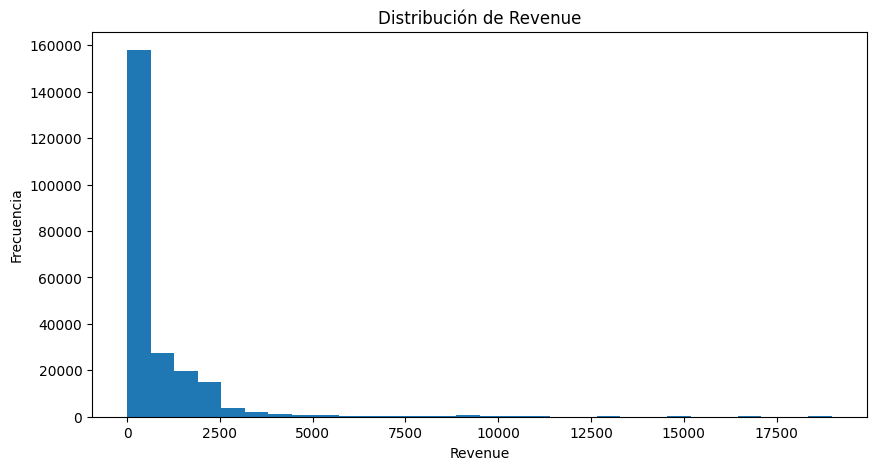

In [33]:
plt.figure(figsize=(10,5))
plt.hist(df["Revenue"], bins=30)
plt.title("Distribución de Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frecuencia")
plt.show();

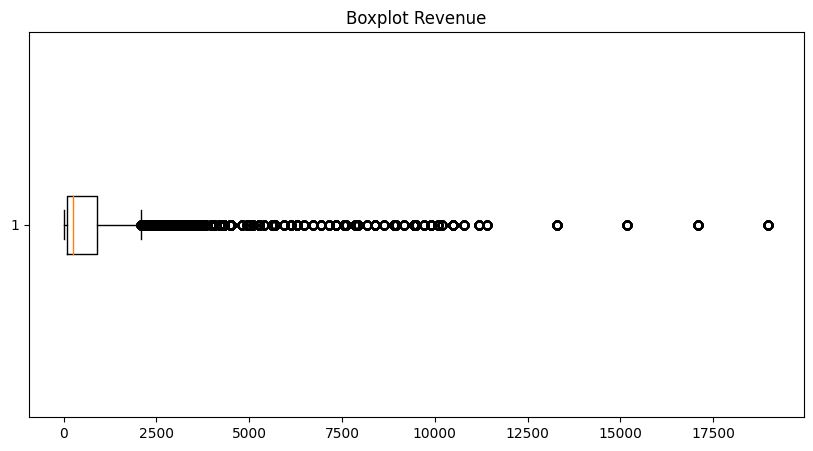

In [34]:
plt.figure(figsize=(10,5))
plt.boxplot(df["Revenue"], vert=False)
plt.title("Boxplot Revenue")
plt.show()

In [35]:
df["Quantity"].describe()

count    231412.000000
mean         40.235182
std          55.138491
min           1.000000
25%           5.000000
50%          10.000000
75%          60.000000
max         360.000000
Name: Quantity, dtype: float64

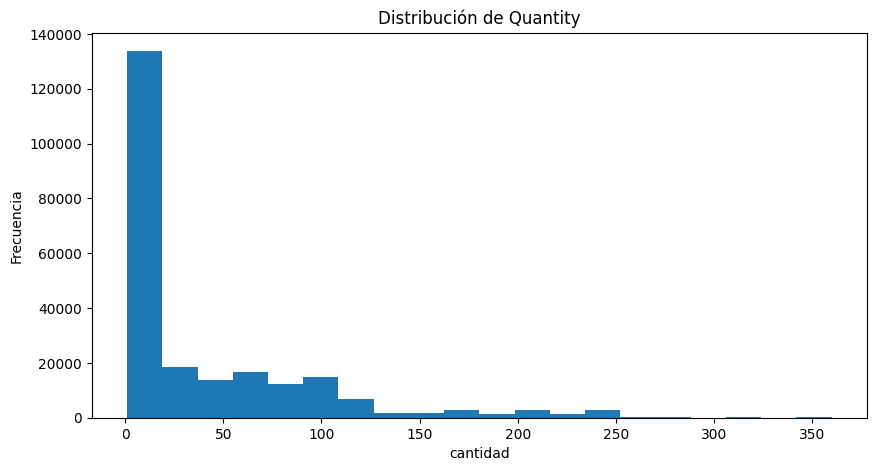

In [36]:
plt.figure(figsize=(10,5))
plt.hist(df["Quantity"], bins=20)
plt.title("Distribución de Quantity")
plt.xlabel("cantidad")
plt.ylabel("Frecuencia")
plt.show()

In [37]:
df["SaleUnitPrice"].describe()

count    231412.000000
mean         45.207066
std         138.949335
min           0.660000
25%          13.000000
50%          18.000000
75%          32.000000
max        1899.000000
Name: SaleUnitPrice, dtype: float64

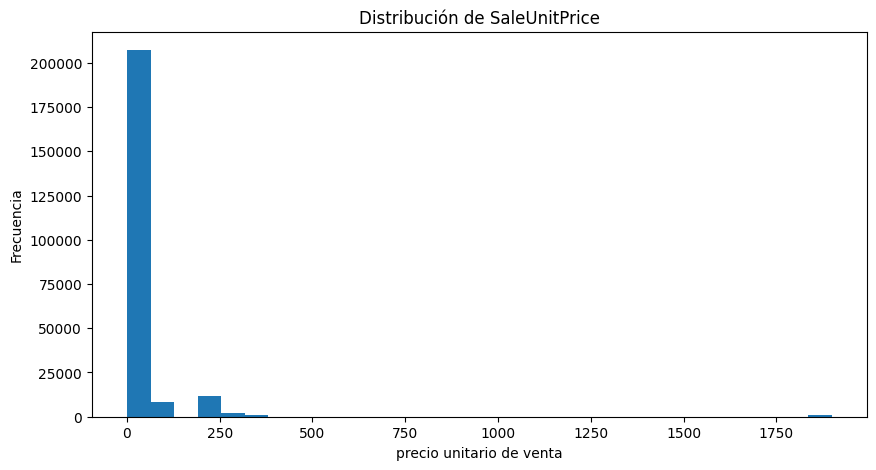

In [38]:
plt.figure(figsize=(10,5))
plt.hist(df["SaleUnitPrice"], bins=30)
plt.title("Distribución de SaleUnitPrice")
plt.xlabel("precio unitario de venta")
plt.ylabel("Frecuencia")
plt.show();

In [39]:
df["PaymentDays"].describe()

count    231412.0
mean          7.0
std           0.0
min           7.0
25%           7.0
50%           7.0
75%           7.0
max           7.0
Name: PaymentDays, dtype: float64

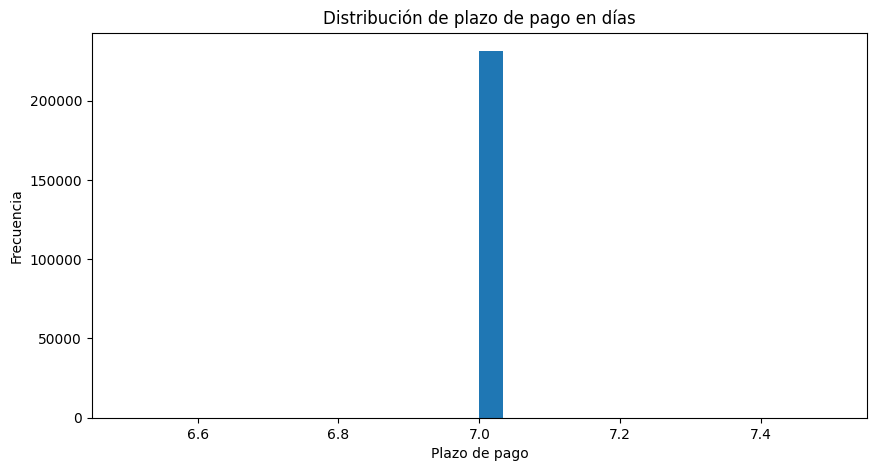

In [40]:
plt.figure(figsize=(10,5))
plt.hist(df["PaymentDays"], bins=30)
plt.title("Distribución de plazo de pago en días")
plt.xlabel("Plazo de pago")
plt.ylabel("Frecuencia")
plt.show();

###  Feature Engineering
#### Métricas de Ventas

In [41]:
# verificamos si el revenue que tenemos está bien o hay que calcularlo por nosotros mismos y descubrimos que el revenue está correctamente calculado
df["CalculatedRevenue"] = df["Quantity"] * df["SaleUnitPrice"]
df[["Revenue", "CalculatedRevenue"]].head()

,Revenue,CalculatedRevenue
0,432.0,432.0
1,2160.0,2160.0
2,130.0,130.0
3,104.0,104.0
4,216.0,216.0


In [42]:
(df["Revenue"] - df["CalculatedRevenue"]).describe()

count    2.314120e+05
mean     1.963410e-16
std      1.928641e-14
min     -2.273737e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.273737e-13
dtype: float64

In [43]:
# Revenue total, ¿Cuánto dinero generó WWI en este dataset?
total_revenue = df["Revenue"].sum()
print(f"{total_revenue:,.2f}".replace(",", "."))

177.634.276.40


In [44]:
# revenue por orden ¿Cuáles fueron las órdenes más grandes?
revenue_by_order = (
    df.groupby(["OrderID","CustomerName"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(revenue_by_order.head(10).map(lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")))

OrderID  CustomerName                      
30269    Cong Hoa                              32.026,00
66991    Tailspin Toys (Good Hart, MI)         29.536,00
49943    Wingtip Toys (Nichols Hills, OK)      28.688,60
47596    Wingtip Toys (Knights Landing, CA)    27.640,00
69920    Raj Verma                             27.382,00
72045    Wingtip Toys (Leathersville, GA)      27.366,00
40366    Tailspin Toys (Medicine Lodge, KS)    27.306,00
61568    Wingtip Toys (Dunkerton, IA)          27.161,00
17103    Tailspin Toys (New Lexington, OH)     26.787,00
17181    Wingtip Toys (Taft Heights, CA)       26.645,00
Name: Revenue, dtype: object


In [45]:
# Revenue por cliente ¿Quiénes son los clientes más valiosos?
revenue_by_customer = (
    df.groupby("CustomerName")["Revenue"].sum().sort_values(ascending = False)
)
# Muestra los 10 primeros con el formato de puntos
print(revenue_by_customer.head(10).map(lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")))

CustomerName
Tailspin Toys (Inguadona, MN)        384.393,35
Tailspin Toys (Minidoka, ID)         379.660,70
Mauno Laurila                        377.189,80
Wingtip Toys (Sarversville, PA)      372.350,00
Ingrida Zeltina                      368.067,45
Tailspin Toys (Long Meadow, MD)      367.258,50
Nasrin Omidzadeh                     366.883,75
Wingtip Toys (Cuyamungue, NM)        365.915,45
Wingtip Toys (San Jacinto, CA)       365.330,95
Wingtip Toys (Morrison Bluff, AR)    360.652,80
Name: Revenue, dtype: object


In [46]:
# Revenue por ciudad ¿Qué ciudades generan más ingresos?
revenue_by_city = (
    df.groupby("CityName")["Revenue"].sum().sort_values(ascending = False)
)
print(revenue_by_city.head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x",".")))

CityName
Sinclair              584.914,00
Teutopolis            568.634,75
Akhiok                562.585,20
East Fultonham        560.753,45
Cherry Grove Beach    536.965,15
Rockwall              530.549,10
Inguadona             384.393,35
Minidoka              379.660,70
North Eaton           377.189,80
Sarversville          372.350,00
Name: Revenue, dtype: object


In [47]:
# revenue por producto, productos estrella
revenue_by_product = (
    df.groupby("StockItemName")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(revenue_by_product.head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x",".")))

StockItemName
Air cushion machine (Blue)                  11.107.251,00
32 mm Anti static bubble wrap (Blue) 50m     6.384.000,00
10 mm Anti static bubble wrap (Blue) 50m     6.329.070,00
20 mm Double sided bubble wrap 50m           6.214.320,00
32 mm Double sided bubble wrap 50m           6.190.240,00
10 mm Double sided bubble wrap 50m           5.943.000,00
20 mm Anti static bubble wrap (Blue) 50m     5.795.640,00
32 mm Anti static bubble wrap (Blue) 20m     2.900.160,00
Void fill 400 L bag (White) 400L             2.871.500,00
20 mm Anti static bubble wrap (Blue) 20m     2.468.700,00
Name: Revenue, dtype: object


In [48]:
# revenue por vendedor ¿Qué vendedores generan más revenue?
revenue_by_vendor = (
    df.groupby("Vendor")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)
print(revenue_by_vendor.head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x",".")))

Vendor
Archer Lamble         18.551.146,95
Kayla Woodcock        18.107.095,00
Hudson Onslow         17.815.605,10
Taj Shand             17.812.364,60
Sophia Hinton         17.768.199,25
Hudson Hollinworth    17.716.354,25
Jack Potter           17.621.145,20
Lily Code             17.612.639,80
Amy Trefl             17.329.344,05
Anthony Grosse        17.300.382,20
Name: Revenue, dtype: object


In [49]:
# Ticket promedio Average Ticket=Total Revenue/Total Orders ¿Cuánto dinero genera, en promedio, una orden?

average_ticket = (
    df["Revenue"].sum()
    /
    df["OrderID"].nunique()
)

print(f"{average_ticket:,.2f}".replace(",", "."))

2.413.67


In [50]:
# cantidad de productos por orden ¿Las órdenes suelen tener pocos o muchos productos?
products_per_order = (
    df.groupby("OrderID")["StockItemID"]
    .count()
)

products_per_order.describe()

count    73595.000000
mean         3.144398
std          1.291288
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: StockItemID, dtype: float64

In [51]:
# revenue por orden ¿Cual es el promedio de ganancia por cada orden?
revenue_per_order = (
    df.groupby("OrderID")["Revenue"]
    .sum()
)
revenue_per_order.describe()

count    73595.000000
mean      2413.673163
std       2700.489487
min          4.800000
25%        703.000000
50%       1673.600000
75%       2987.000000
max      32026.000000
Name: Revenue, dtype: float64

In [52]:
# órdenes por cliente ¿Por qué .nunique()? Porque: una orden puede tener varias línea y aparecer repetida muchas veces.
orders_per_customer = (
    df.groupby("CustomerID")["OrderID"]
    .nunique()
)

orders_per_customer.describe()

count    663.000000
mean     111.003017
std       20.617653
min        4.000000
25%      106.000000
50%      114.000000
75%      122.000000
max      150.000000
Name: OrderID, dtype: float64

#### Métricas operativas

In [55]:
# Fill rate qué porcentaje de lo pedido realmente fue despachado.Fill rate = PickedQuantity/Quantity x 100
# creamos la columna PickedQuantity
df["FillRate"] = (
    df["PickedQuantity"] / df["Quantity"]
) * 100
df[["StockItemName","Quantity", "PickedQuantity", "FillRate"]].head()

,StockItemName,Quantity,PickedQuantity,FillRate
0,Halloween zombie mask (Light Brown) M,24,24,100.0
1,"""The Gu"" red shirt XML tag t-shirt (Black) 5XL",120,120,100.0
2,Developer joke mug - that's a hardware problem...,10,10,100.0
3,DBA joke mug - I will get you in order (White),8,8,100.0
4,Halloween skull mask (Gray) M,12,12,100.0


In [56]:
# Global Fill Rate =  ∑PickedQuantity/ ∑Quantity x 100

global_fill_rate = (
    df["PickedQuantity"].sum() / df["Quantity"].sum()
)*100
global_fill_rate

96.13060128210967

In [58]:
# Pending Quantity = Quantity - PickedQuantity  que el cliente pidió PERO no fue despachada.
df["PendingQuantity"] = (
    df["Quantity"] - df["PickedQuantity"]
)
df[["StockItemName","Quantity", "PickedQuantity","FillRate", "PendingQuantity"]].head()

,StockItemName,Quantity,PickedQuantity,FillRate,PendingQuantity
0,Halloween zombie mask (Light Brown) M,24,24,100.0,0
1,"""The Gu"" red shirt XML tag t-shirt (Black) 5XL",120,120,100.0,0
2,Developer joke mug - that's a hardware problem...,10,10,100.0,0
3,DBA joke mug - I will get you in order (White),8,8,100.0,0
4,Halloween skull mask (Gray) M,12,12,100.0,0


In [59]:
# Productos con más pendientes ¿Qué productos tienen más problemas de despacho?
pending_by_product = (
    df.groupby("StockItemName")["PendingQuantity"] .sum().sort_values(ascending=False)
)
pending_by_product.head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x","."))

StockItemName
Black and orange glass with care despatch tape 48mmx75m    67.296,00
"The Gu" red shirt XML tag t-shirt (White) 5XL             45.204,00
"The Gu" red shirt XML tag t-shirt (Black) 4XL             44.616,00
"The Gu" red shirt XML tag t-shirt (White) XS              44.004,00
Shipping carton (Brown) 305x305x305mm                      41.800,00
"The Gu" red shirt XML tag t-shirt (White) XXS             40.824,00
Tape dispenser (Red)                                       32.600,00
"The Gu" red shirt XML tag t-shirt (White) M               21.972,00
"The Gu" red shirt XML tag t-shirt (Black) XL              21.960,00
"The Gu" red shirt XML tag t-shirt (Black) 3XL                  0,00
Name: PendingQuantity, dtype: object

In [61]:
# Fill Rate por producto
fillrate_by_product = (
    df.groupby("StockItemName")[["PickedQuantity", "Quantity"]]
    .sum()
)

fillrate_by_product["FillRate"] = (
    fillrate_by_product["PickedQuantity"]
    /
    fillrate_by_product["Quantity"]
) * 100

fillrate_by_product.sort_values(
    by="FillRate"
).head(10)

,PickedQuantity,Quantity,FillRate
StockItemName,,,
"""The Gu"" red shirt XML tag t-shirt (White) 5XL",23268,68472,33.981774
"""The Gu"" red shirt XML tag t-shirt (Black) 4XL",23244,67860,34.252874
"""The Gu"" red shirt XML tag t-shirt (White) XS",23196,67200,34.517857
"""The Gu"" red shirt XML tag t-shirt (White) XXS",23328,64152,36.363636
Tape dispenser (Red),23630,56230,42.023831
Black and orange glass with care despatch tape 48mmx75m,58200,125496,46.375980
"""The Gu"" red shirt XML tag t-shirt (Black) XL",46500,68460,67.922875
"""The Gu"" red shirt XML tag t-shirt (White) M",47100,69072,68.189715
Shipping carton (Brown) 305x305x305mm,110075,151875,72.477366


In [64]:
# Fill Rate por ciudad
fillrate_by_city = (
    df.groupby("CityName")[["PickedQuantity", "Quantity"]]
    .sum()
)

fillrate_by_city["FillRate"] = (
    fillrate_by_city["PickedQuantity"]
    /
    fillrate_by_city["Quantity"]
) * 100

fillrate_by_city.sort_values(
    by="FillRate"
).head(10)

,PickedQuantity,Quantity,FillRate
CityName,,,
Roberta Mill,3054,3728,81.920601
Yampa,2390,2877,83.072645
Rogersville,3327,3766,88.343070
Staley,8839,9873,89.526993
Sayner,14629,16257,89.985852
Morton Grove,9423,10325,91.263923
Ashtabula,13927,15248,91.336569
Moroni,7487,8171,91.628932
Orick,13425,14640,91.700820


#### Interpretación del análisis operativo
##### Análisis del cumplimiento de despacho (Fill Rate)

Con el objetivo de evaluar el desempeño operativo y logístico de WWI, se realizó un análisis del nivel de cumplimiento de despacho utilizando la métrica Fill Rate, la cual compara las cantidades solicitadas por los clientes frente a las cantidades efectivamente despachadas.

La compañía presentó un Fill Rate global de aproximadamente 96.13%, lo que indica que, en términos generales, la operación logística mantiene un alto nivel de cumplimiento en los pedidos realizados por los clientes.

Este resultado sugiere que la empresa posee una cadena de abastecimiento relativamente eficiente y una buena capacidad para responder a la demanda comercial.

##### Productos con incumplimientos de despacho

El análisis permitió identificar únicamente 9 productos con diferencias entre las cantidades solicitadas y las cantidades despachadas, lo que representa una proporción muy reducida respecto al total de productos comercializados.

Sin embargo, aunque el número de productos afectados es bajo, algunos presentan niveles de cumplimiento considerablemente reducidos, con Fill Rates entre el 33% y el 72%.

Estos valores indican posibles problemas asociados a:

insuficiencia de inventario,
alta demanda,
dificultades de abastecimiento,
problemas operativos de picking,
o limitaciones logísticas específicas.

Particularmente, los productos con niveles de cumplimiento inferiores al 70% representan un riesgo operativo importante, ya que pueden impactar negativamente:

la satisfacción del cliente,
la continuidad de ventas,
la reputación comercial,
y la disponibilidad de inventario.

Por lo tanto, estos productos deberían priorizarse dentro de futuros análisis de inventario y abastecimiento.

##### Análisis de cumplimiento por ciudad

A nivel geográfico, el desempeño operativo mostró resultados favorables.

La ciudad con menor Fill Rate presentó un cumplimiento cercano al 81%, mientras que únicamente cinco ciudades registraron indicadores inferiores al 90%.

Esto evidencia que el modelo logístico de WWI mantiene un comportamiento relativamente estable entre regiones y que los problemas de despacho no parecen estar asociados de manera generalizada a una ubicación específica.

No obstante, las ciudades con menores niveles de cumplimiento podrían requerir análisis posteriores relacionados con:

tiempos de entrega,
capacidad logística,
disponibilidad regional de inventario,
o comportamiento de la demanda.
Conclusión general

En términos generales, WWI presenta un desempeño operativo sólido, con altos niveles de cumplimiento en la mayoría de pedidos y ciudades analizadas.

Los principales hallazgos del análisis indican que:

el nivel global de cumplimiento es elevado,
los incumplimientos son poco frecuentes,
los problemas operativos parecen concentrarse en productos específicos,
y la operación logística mantiene estabilidad regional.

Los productos identificados con bajos niveles de Fill Rate representan oportunidades claras de mejora para optimizar la disponibilidad de inventario y fortalecer el nivel de servicio ofrecido a los clientes.

#### Métricas Financieras
¿Qué clientes dejan más ganancia?
¿Qué productos son más rentables?
¿Qué vendedores generan más margen?
¿Estamos vendiendo mucho pero ganando poco?
¿Qué proveedores están asociados a productos más rentables?

#### Métricas financieras

In [66]:
# Profit = (SaleUnitPrice - LastCostPrice) x Quantity  La ganancia aproximada: por línea de venta.
df["Profit"] = (
    (df["SaleUnitPrice"] - df["LastCostPrice"]) * df["Quantity"]
)
df[[
    "SaleUnitPrice",
    "LastCostPrice",
    "Quantity",
    "Profit"
]].head()

,SaleUnitPrice,LastCostPrice,Quantity,Profit
0,18.0,19.0,24,-24.0
1,18.0,8.0,120,1200.0
2,13.0,4.5,10,85.0
3,13.0,4.5,8,68.0
4,18.0,15.0,12,36.0


In [67]:
#¿Cuánta ganancia generó WWI?
total_profit = df["Profit"].sum()
print(f"USD {total_profit:,.2f}".replace(",", "."))

USD 88.729.962.50


In [68]:
# ¿Qué clientes son más rentables?
profit_by_customer = (
    df.groupby("CustomerName")["Profit"].sum().sort_values(ascending= False)
)
print(profit_by_customer.head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x",".")))

CustomerName
Ingrida Zeltina                       193.967,35
Wingtip Toys (Sarversville, PA)       192.787,75
Tailspin Toys (Inguadona, MN)         190.993,45
Wingtip Toys (San Jacinto, CA)        190.615,45
Tailspin Toys (Minidoka, ID)          190.035,75
Wingtip Toys (Grabill, IN)            185.302,50
Wingtip Toys (Cuyamungue, NM)         184.957,95
Wingtip Toys (West Frostproof, FL)    184.736,35
Satish Mittal                         184.524,75
Nasrin Omidzadeh                      184.135,60
Name: Profit, dtype: object


In [69]:
# ¿Qué productos generan más ganancia?
profit_by_product = (
    df.groupby("StockItemName")["Profit"].sum().sort_values(ascending= False)
)
print(profit_by_product.head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x",".")))

StockItemName
20 mm Double sided bubble wrap 50m          5.293.680,00
Air cushion machine (Blue)                  4.439.391,00
32 mm Anti static bubble wrap (Blue) 50m    3.526.400,00
10 mm Anti static bubble wrap (Blue) 50m    3.452.220,00
32 mm Double sided bubble wrap 50m          2.929.310,00
10 mm Double sided bubble wrap 50m          2.773.400,00
20 mm Anti static bubble wrap (Blue) 50m    2.670.540,00
32 mm Anti static bubble wrap (Blue) 20m    1.510.500,00
Void fill 400 L bag (White) 400L            1.378.320,00
32 mm Double sided bubble wrap 20m          1.323.190,00
Name: Profit, dtype: object


In [70]:
# ¿Qué vendedores generan mayor rentabilidad?
profit_by_vendor = (
    df.groupby("Vendor")["Profit"].sum().sort_values(ascending= False)
)
print(profit_by_vendor.head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x",".")))

Vendor
Archer Lamble         9.291.341,55
Kayla Woodcock        9.031.442,10
Hudson Onslow         8.948.979,85
Taj Shand             8.907.299,40
Hudson Hollinworth    8.874.496,30
Lily Code             8.821.092,90
Jack Potter           8.811.349,85
Sophia Hinton         8.807.717,90
Amy Trefl             8.650.634,30
Anthony Grosse        8.585.608,35
Name: Profit, dtype: object


In [71]:
# eficiencia financiera. Margin% = Profit/Revenue x 100
df["MarginPercent"] = (
    df["Profit"] / df["Revenue"]
)*100
df[["Revenue", "Profit", "MarginPercent"]].head()

,Revenue,Profit,MarginPercent
0,432.0,-24.0,-5.555556
1,2160.0,1200.0,55.555556
2,130.0,85.0,65.384615
3,104.0,68.0,65.384615
4,216.0,36.0,16.666667


In [72]:
# Average margin = ∑Profit / ∑Revenue x100
average_margin = (
    df["Profit"].sum() /df["Revenue"].sum()
)*100
print(f"%{average_margin:,.2f}".replace(",", "."))

%49.95


In [75]:
# No se usa .mean() porque: promedia porcentajes individuale y distorsiona el resultado, se usa Average margin = ∑Profit / ∑Revenue x100. 

df["MarginPercent"].mean().round(2)

53.81

In [76]:
# ¿Qué productos son MÁS eficientes financieramente?
margin_by_product = (
    df.groupby("StockItemName")[[ "Revenue","Profit"]].sum() #Agrupa por producto y calcula: Profit total y Revenue total
)

margin_by_product["MarginPercent"] = (
    margin_by_product["Profit"]
    /
    margin_by_product["Revenue"] #Margin %= profit (ganancia)/Revenue (ingresos) x 100 para CADA producto.
) * 100
margin_by_product.sort_values(by="MarginPercent", ascending=False).head(10).style.format(
    lambda x: f"{x:,.2f}".replace(",", "x").replace(".", ",").replace("x", ".")
)

#Revenue ¿cuánto vende?, Profit ¿cuánto gana?, MarginPercent ¿qué tan rentable es? 

,Revenue,Profit,MarginPercent
StockItemName,,,
20 mm Double sided bubble wrap 50m,"6.214.320,00","5.293.680,00","85,19"
Dinosaur battery-powered slippers (Green) M,"192.736,00","144.552,00","75,00"
Dinosaur battery-powered slippers (Green) L,"196.064,00","147.048,00","75,00"
Dinosaur battery-powered slippers (Green) S,"186.976,00","140.232,00","75,00"
Furry gorilla with big eyes slippers (Black) L,"190.176,00","142.632,00","75,00"
Furry gorilla with big eyes slippers (Black) M,"185.536,00","139.152,00","75,00"
Furry gorilla with big eyes slippers (Black) S,"186.112,00","139.584,00","75,00"
Animal with big feet slippers (Brown) M,"180.000,00","135.000,00","75,00"
Animal with big feet slippers (Brown) L,"185.120,00","138.840,00","75,00"


#### Métricas de inventario
¿Qué productos rotan más?
¿Qué productos casi no se venden?
¿Dónde hay riesgo de desabastecimiento?
¿Qué productos tienen sobrestock?
¿Qué productos necesitan resurtido?

In [77]:
# ¿Qué productos se venden más?
product_rotation = (
    df.groupby("StockItemName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(product_rotation.head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x",".")))

StockItemName
Black and orange fragile despatch tape 48mmx75m     207.324,00
Black and orange fragile despatch tape 48mmx100m    193.680,00
Clear packaging tape 48mmx75m                       158.626,00
3 kg Courier post bag (White) 300x190x95mm          152.375,00
Shipping carton (Brown) 356x356x279mm               152.125,00
Shipping carton (Brown) 305x305x305mm               151.875,00
Express post box 5kg (White) 350x280x130mm          149.825,00
Shipping carton (Brown) 413x285x187mm               147.675,00
Shipping carton (Brown) 229x229x229mm               146.375,00
Shipping carton (Brown) 457x457x457mm               144.950,00
Name: Quantity, dtype: object


In [78]:
# ¿Cuánto inventario tenemos?
stock_by_product = (
     df.groupby("StockItemName")["QuantityOnHand"]
    .max() #usamos max() para capturar el valor real, no sum()
    .sort_values(ascending=False)
)

print(stock_by_product.head(10).map(lambda x: f"{x:,.2f}".replace(",","x").replace(".",",").replace("x",".")))

StockItemName
Express post box 5kg (White) 350x280x130mm                    1.034.169,00
Shipping carton (Brown) 356x356x279mm                           723.037,00
Black and orange fragile despatch tape 48mmx75m                 686.530,00
Black and orange handle with care despatch tape  48mmx100m      654.741,00
Black and orange fragile despatch tape 48mmx100m                618.169,00
Furry animal socks (Pink) L                                     570.360,00
"The Gu" red shirt XML tag t-shirt (Black) 3XL                  525.771,00
Furry animal socks (Pink) S                                     501.745,00
Large sized bubblewrap roll 50m                                 440.171,00
Shipping carton (Brown) 457x457x457mm                           422.709,00
Name: QuantityOnHand, dtype: object


In [79]:
# Inventory Turnover Ratio. Inventory Rotation = QuantitySold/QuantityOnHand  qué tan rápido se mueve el inventario.
inventory_rotation = (
    df.groupby("StockItemName")
    .agg({
        "Quantity": "sum",
        "QuantityOnHand": "max"
    })
)

inventory_rotation["RotationRatio"] = (
    inventory_rotation["Quantity"]
    /
    inventory_rotation["QuantityOnHand"]
)
inventory_rotation.sort_values(by="RotationRatio", ascending=False).head(10).style.format(
    lambda x: f"{x:,.2f}".replace(",", "x").replace(".", ",").replace("x", ".")
)

,Quantity,QuantityOnHand,RotationRatio
StockItemName,,,
"""The Gu"" red shirt XML tag t-shirt (White) 5XL","68.472,00","3,00","22.824,00"
"""The Gu"" red shirt XML tag t-shirt (White) XS","67.200,00","16,00","4.200,00"
Shipping carton (Brown) 305x305x305mm,"151.875,00","38,00","3.996,71"
"""The Gu"" red shirt XML tag t-shirt (White) M","69.072,00","20,00","3.453,60"
"""The Gu"" red shirt XML tag t-shirt (Black) 4XL","67.860,00","25,00","2.714,40"
Black and orange glass with care despatch tape 48mmx75m,"125.496,00","50,00","2.509,92"
"""The Gu"" red shirt XML tag t-shirt (White) XXS","64.152,00","27,00","2.376,00"
Tape dispenser (Red),"56.230,00","24,00","2.342,92"
"""The Gu"" red shirt XML tag t-shirt (Black) XL","68.460,00","48,00","1.426,25"


In [80]:
# productos que podrían agotarse. ¿Qué productos tienen poco inventario disponible?
low_stock = (
    inventory_rotation[
        inventory_rotation["QuantityOnHand"] < 50
    ]
)
low_stock .head(10)

,Quantity,QuantityOnHand,RotationRatio
StockItemName,,,
"""The Gu"" red shirt XML tag t-shirt (Black) 4XL",67860,25,2714.400000
"""The Gu"" red shirt XML tag t-shirt (Black) XL",68460,48,1426.250000
"""The Gu"" red shirt XML tag t-shirt (White) 5XL",68472,3,22824.000000
"""The Gu"" red shirt XML tag t-shirt (White) M",69072,20,3453.600000
"""The Gu"" red shirt XML tag t-shirt (White) XS",67200,16,4200.000000
"""The Gu"" red shirt XML tag t-shirt (White) XXS",64152,27,2376.000000
Shipping carton (Brown) 305x305x305mm,151875,38,3996.710526
Tape dispenser (Red),56230,24,2342.916667


In [82]:
#Productos: con mucho stock PERO: poca venta.
overstock = (
    inventory_rotation[
        inventory_rotation["RotationRatio"] < 0.1
    ]
)
overstock.head(10)


,Quantity,QuantityOnHand,RotationRatio
StockItemName,,,
DBA joke mug - I will get you in order (White),5585,57083,0.097840
DBA joke mug - SELECT caffeine FROM mug (White),5797,61071,0.094922
DBA joke mug - daaaaaa-ta (Black),5724,68800,0.083198
DBA joke mug - daaaaaa-ta (White),6014,89207,0.067416
DBA joke mug - it depends (White),5922,72747,0.081405
DBA joke mug - mind if I join you? (Black),5402,62428,0.086532
DBA joke mug - two types of DBAs (Black),5767,80978,0.071217
DBA joke mug - you might be a DBA if (Black),5845,68683,0.085101
DBA joke mug - you might be a DBA if (White),5733,66722,0.085924


In [84]:
#Productos muy vendidos pero con poco inventario
critical_products = (
    inventory_rotation[
        (inventory_rotation["QuantityOnHand"] < 50)
        &
        (inventory_rotation["RotationRatio"] > 1)
    ]
)
critical_products.head(10)

,Quantity,QuantityOnHand,RotationRatio
StockItemName,,,
"""The Gu"" red shirt XML tag t-shirt (Black) 4XL",67860,25,2714.400000
"""The Gu"" red shirt XML tag t-shirt (Black) XL",68460,48,1426.250000
"""The Gu"" red shirt XML tag t-shirt (White) 5XL",68472,3,22824.000000
"""The Gu"" red shirt XML tag t-shirt (White) M",69072,20,3453.600000
"""The Gu"" red shirt XML tag t-shirt (White) XS",67200,16,4200.000000
"""The Gu"" red shirt XML tag t-shirt (White) XXS",64152,27,2376.000000
Shipping carton (Brown) 305x305x305mm,151875,38,3996.710526
Tape dispenser (Red),56230,24,2342.916667


In [85]:
df.columns

Index(['OrderDate', 'OrderID', 'CustomerName', 'CustomerID', 'PaymentDays',
       'CityName', 'StockItemName', 'StockItemID', 'Brand', 'SupplierName',
       'SupplierID', 'SupplierCategoryID', 'Vendor', 'VendorID', 'Quantity',
       'PickedQuantity', 'SaleUnitPrice', 'TaxRate', 'QuantityOnHand',
       'LastCostPrice', 'Revenue', 'CalculatedRevenue', 'FillRate',
       'PendingQuantity', 'Profit', 'MarginPercent'],
      dtype='object')

In [86]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231412 entries, 0 to 231411
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   OrderDate           231412 non-null  datetime64[ns]
 1   OrderID             231412 non-null  int32         
 2   CustomerName        231412 non-null  object        
 3   CustomerID          231412 non-null  int32         
 4   PaymentDays         231412 non-null  int32         
 5   CityName            231412 non-null  object        
 6   StockItemName       231412 non-null  object        
 7   StockItemID         231412 non-null  int32         
 8   Brand               231412 non-null  object        
 9   SupplierName        231412 non-null  object        
 10  SupplierID          231412 non-null  int32         
 11  SupplierCategoryID  231412 non-null  int32         
 12  Vendor              231412 non-null  object        
 13  VendorID            231412 no

In [87]:
df.isnull().sum()

OrderDate             0
OrderID               0
CustomerName          0
CustomerID            0
PaymentDays           0
CityName              0
StockItemName         0
StockItemID           0
Brand                 0
SupplierName          0
SupplierID            0
SupplierCategoryID    0
Vendor                0
VendorID              0
Quantity              0
PickedQuantity        0
SaleUnitPrice         0
TaxRate               0
QuantityOnHand        0
LastCostPrice         0
Revenue               0
CalculatedRevenue     0
FillRate              0
PendingQuantity       0
Profit                0
MarginPercent         0
dtype: int64

In [88]:
df.duplicated().sum()

0

In [89]:
# redondear cifras, decimales excesivos
Columnas_decimales = ["TaxRate", "Revenue","SaleUnitPrice","Profit","LastCostPrice","MarginPercent","FillRate"]
df[Columnas_decimales] = df[Columnas_decimales].round(2)
df.head()

,OrderDate,OrderID,CustomerName,CustomerID,PaymentDays,CityName,StockItemName,StockItemID,Brand,SupplierName,...,SaleUnitPrice,TaxRate,QuantityOnHand,LastCostPrice,Revenue,CalculatedRevenue,FillRate,PendingQuantity,Profit,MarginPercent
0,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,Halloween zombie mask (Light Brown) M,143,Unbranded,"Fabrikam, Inc.",...,18.0,15,378187,19.0,432.0,432.0,100.0,0,-24.0,-5.56
1,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,"""The Gu"" red shirt XML tag t-shirt (Black) 5XL",99,Unbranded,"Fabrikam, Inc.",...,18.0,15,282132,8.0,2160.0,2160.0,100.0,0,1200.0,55.56
2,2014-07-25,31523,"Wingtip Toys (Sunburg, MN)",468,7,Sunburg,Developer joke mug - that's a hardware problem...,33,Unbranded,Graphic Design Institute,...,13.0,15,60005,4.5,130.0,130.0,100.0,0,85.0,65.38
3,2014-07-25,31549,Shantanu Huq,930,7,Cramerton,DBA joke mug - I will get you in order (White),24,Unbranded,Graphic Design Institute,...,13.0,15,57083,4.5,104.0,104.0,100.0,0,68.0,65.38
4,2014-07-25,31549,Shantanu Huq,930,7,Cramerton,Halloween skull mask (Gray) M,147,Unbranded,"Fabrikam, Inc.",...,18.0,15,354456,15.0,216.0,216.0,100.0,0,36.0,16.67


In [ ]:
df.to_csv(
    "../data/wwi_analytics_dataset.csv",
    sep=";",
    index=False
)
df.to_csv(
    "/mnt/c/Users/G_Ardila/OneDrive/Desktop/wwi_analytics_dataset.csv",
    sep=";",
    index=False
)